In [1]:
from torchvision.datasets import GTSRB
from torchvision import transforms 
import torch
import torch.nn as nn
from torch.optim import Adam
import  torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torch.utils.data import DataLoader  
import torchvision.io as tv_io
from PIL import  Image
device=torch.device("cpu")
class MyConvBlock( nn.Module ):
    def __init__(self,in_ch,out_ch,dropout_p):
        kernel_size=3
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,kernel_size,stride=1,padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2,stride=2)
        )
    def forward(self,x):
        return self.model(x)

In [2]:
model=torch.load('model.pth',map_location=device, weights_only=False)
next(model.parameters()).device

device(type='cpu')

In [3]:
IMG_WIDTH=64
IMG_HEIGHT=64
process_transform=transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Resize((IMG_WIDTH,IMG_HEIGHT))
])

In [4]:
classes = {
    0: 'Limitation de vitesse (20km/h)',
    1: 'Limitation de vitesse (30km/h)',
    2: 'Limitation de vitesse (50km/h)',
    3: 'Limitation de vitesse (60km/h)',
    4: 'Limitation de vitesse (70km/h)',
    5: 'Limitation de vitesse (80km/h)',
    6: 'Fin de limitation de vitesse (80km/h)',
    7: 'Limitation de vitesse (100km/h)',
    8: 'Limitation de vitesse (120km/h)',
    9: 'Interdiction de dépasser',
    10: 'Interdiction de dépasser (véhicules > 3.5t)',
    11: 'Priorité au prochain carrefour',
    12: 'Route prioritaire',
    13: 'Cédez le passage',
    14: 'Stop',
    15: 'Circulation interdite',
    16: 'Interdit aux véhicules > 3.5t',
    17: 'Sens interdit',
    18: 'Danger général',
    19: 'Virage dangereux à gauche',
    20: 'Virage dangereux à droite',
    21: 'Double virage',
    22: 'Route cahoteuse',
    23: 'Route glissante',
    24: 'Chaussée rétrécie à droite',
    25: 'Travaux',
    26: 'Feux tricolores',
    27: 'Passage piétons',
    28: 'Passage enfants',
    29: 'Passage cyclistes',
    30: 'Attention neige/verglas',
    31: 'Passage d\'animaux sauvages',
    32: 'Fin de toutes les limitations',
    33: 'Obligation tourner à droite',
    34: 'Obligation tourner à gauche',
    35: 'Obligation tout droit',
    36: 'Obligation tout droit ou à droite',
    37: 'Obligation tout droit ou à gauche',
    38: 'Contournement obligatoire à droite',
    39: 'Contournement obligatoire à gauche',
    40: 'Carrefour giratoire obligatoire',
    41: 'Fin d\'interdiction de dépasser',
    42: 'Fin d\'interdiction de dépasser (véhicules > 3.5t)'
}
def predict_sign(image_path):
    image = Image.open(image_path).convert('RGB')
    processed_image=process_transform(image)
    batched_image=processed_image.unsqueeze(0)
    batched_image_cpu=batched_image.to(device)
    with torch.no_grad():
        output=model(batched_image_cpu)
        prediction=output.argmax(dim=1).item()
        predicted_sign=classes[prediction]
    return predicted_sign
def show_image(image_path):
    image=mpimg.imread(image_path)
    plt.imshow(image,cmap='gray')
    

In [5]:
from pathlib import Path

print(Path.cwd())
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

DATA_DIR.mkdir(exist_ok=True)

C:\Users\user\deep-learning-traffic-signs\notebooks


In [6]:
train_dataset = GTSRB(
    root=str(DATA_DIR),
    split="train",
    transform=None,
    download=True
)
test_dataset = GTSRB(
    root=str(DATA_DIR),
    split="test",
    transform=None,
    download=True
)

In [7]:
image_path = train_dataset._samples[100][0]

print(image_path)

C:\Users\user\deep-learning-traffic-signs\data\gtsrb\GTSRB\Training\00000\00003_00010.ppm


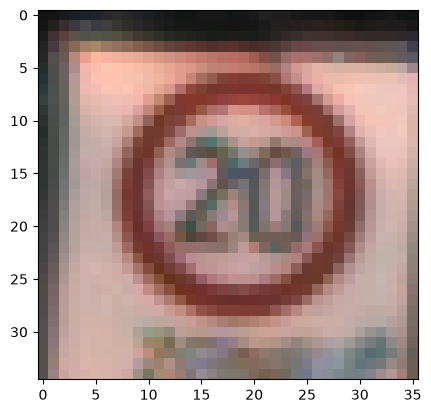

In [8]:
show_image(image_path)

In [9]:
res=predict_sign(image_path)
print(res)

Limitation de vitesse (20km/h)


In [10]:
image_path = train_dataset._samples[1500][0]

print(image_path)

C:\Users\user\deep-learning-traffic-signs\data\gtsrb\GTSRB\Training\00001\00045_00000.ppm


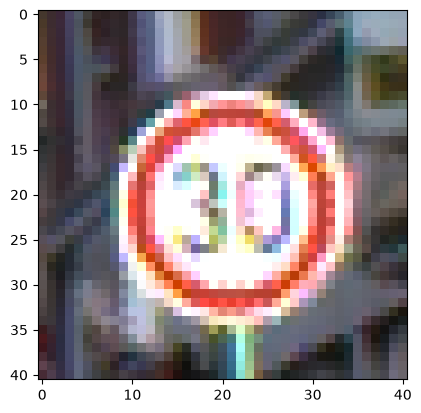

In [11]:
show_image(image_path)

In [12]:
res=predict_sign(image_path)
print(res)

Limitation de vitesse (30km/h)


In [13]:
image_path = train_dataset._samples[10010][0]

print(image_path)


C:\Users\user\deep-learning-traffic-signs\data\gtsrb\GTSRB\Training\00010\00003_00020.ppm


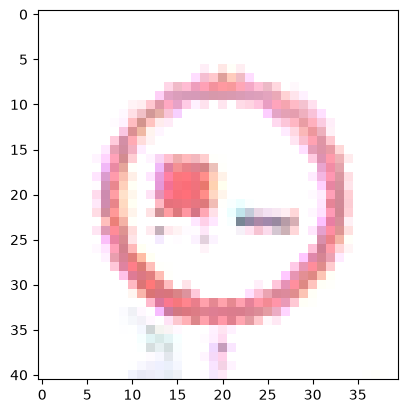

In [14]:
show_image(image_path)

In [15]:
res=predict_sign(image_path)
print(res)

Interdiction de dépasser (véhicules > 3.5t)


In [16]:
image_path = test_dataset._samples[10010][0]

print(image_path)

C:\Users\user\deep-learning-traffic-signs\data\gtsrb\GTSRB\Final_Test\Images\10010.ppm


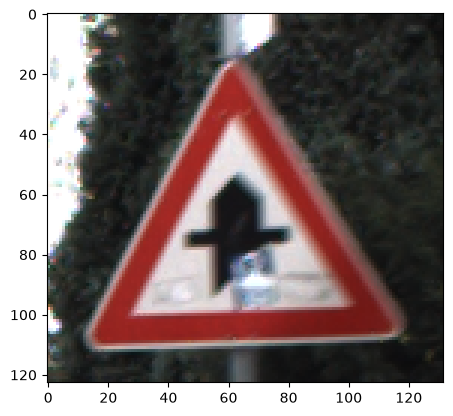

In [17]:
show_image(image_path)

In [18]:
res=predict_sign(image_path)
print(res)

Priorité au prochain carrefour


C:\Users\user\deep-learning-traffic-signs\data\gtsrb\GTSRB\Final_Test\Images\02000.ppm
Obligation tourner à gauche


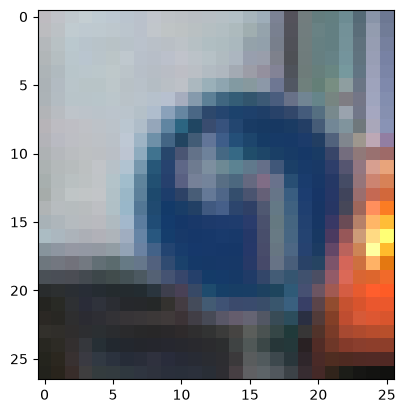

In [19]:
image_path = test_dataset._samples[2000][0]

print(image_path)
show_image(image_path)
res=predict_sign(image_path)
print(res)